# Project 3
# Mental Health and CGPA: A Classification Study of Student Performance

https://www.kaggle.com/datasets/sonia22222/students-mental-health-assessments/data

## Introductions
**Michael Shahine** uniqname: *shahine*

Hi teaching team, I am a first year MSI student I come from a background mainly in front end development and was interested in MSI based on a recommendation from my friend in the program + an interest in Basketball analytics and business analytics. I play club Water Polo for the University in my free time, and play a lot basketball as well.

**Rebecca Falash:** uniqname: *rfalash*

I am a second year Dual degree student studying Geospatial data science at SEAS and Big Data at UMSI. I am interested in electrification, environmental modeling, and load analysis. In my free time I race on the UM cycling team. 

**Mason Fisher:** uniqname: *masonaf*

Hi teaching team, I am a first year MSI student. I come from a background in commmunications, but I am currently working for the football team as a sports scientist. I am interesting in sports analytics. In my free time, I enjoy reading and playing basketball. 


**Overview**

As a team we decided to study the influence of social media and outward pressures on a students performance at school. We have included two datasets for our analysis which includes a social media user activity dataset that contains information on students habit activities as well as other demographic information such as gender, income level, relationship status, etc. This dataset will help us identify patterns that are connected to the specific habits the student have and its connection to other lifestyle factors. The second dataset is the student mental health assessments which contains information on a students mental health in broken down variables including stress, depression, and anxiety levels. For our analysis, we grouped and averaged the data by age and gender to study the patterns between lifestyle factors and mental health outcomes.

**Motivation**
We chose this topic for our project because we understand the pressures that come with being a student. As a team we wanted to better understand how outside factors can influence our mental health. We wanted to see what sort of habits have an effect on us as students and if there was any differences based off of things like age, gender, gpa etc. This is more and more relevant with the increasing amount of technology nowadays and the less and less time people are spending doing outside activities, making researching this even more important. We take a deeper look at this below and start to paint a picture. 

**Data Sources**

1. https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance

2. https://www.kaggle.com/datasets/sonia22222/students-mental-health-assessments/data

NOTE: The Student Habits vs Academic Performance Data set is a simulated data set and for this project we only used the Students mental health assessments data.

These two datasets compliment each other because one captures behaviors and demographics such as social media usage, sleep, and study habits. While the other captures mental health outcomes such as stress, anxiety, and depression. When using both together you can study the connection between lifestyle factors, mental health, and academic performance in relation to age and gender.


# Machine Learning Goal
1. How does Mental Health Factors Affect GPA
- We will look at this through classification 

## Preprocessing Data

In [32]:
import csv
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder


In [33]:
df = pd.read_csv('df_MH_export.csv')

### Data cleaning and handling of issues: 20 points


In [34]:
print("Missing by column:\n", df.isna().sum().sort_values(ascending=False))

Missing by column:
 Substance_Use                  15
CGPA                           12
Course                          0
Age                             0
Gender                          0
Stress_Level                    0
Anxiety_Score                   0
Depression_Score                0
Physical_Activity               0
Diet_Quality                    0
Social_Support                  0
Sleep_Quality                   0
Relationship_Status             0
Counseling_Service_Use          0
Family_History                  0
Chronic_Illness                 0
Financial_Stress                0
Extracurricular_Involvement     0
Semester_Credit_Load            0
Residence_Type                  0
dtype: int64


In [35]:
df = df.dropna(subset=["CGPA"]) #remove rows with missing CGPA because its our target variable

df['CGPA_bin'] = pd.cut(df['CGPA'], bins=[0, 2, 3.3, 4.0], labels=['low', 'medium', 'high'])
df = df.drop(columns=["CGPA"]) #drop CGPA from the features dataframe

df.head()

,Age,Course,Gender,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type,CGPA_bin
0,25,Others,Male,3,3,2,Good,Moderate,Good,Moderate,Married,Never,Never,No,No,2,Moderate,17,On-Campus,high
1,24,Engineering,Female,0,3,0,Average,Low,Average,Low,Single,Occasionally,Occasionally,No,No,3,Low,27,On-Campus,medium
2,19,Business,Female,4,0,3,Good,Low,Average,Moderate,In a Relationship,Never,Occasionally,No,No,4,High,15,On-Campus,high
3,19,Computer Science,Male,2,1,0,Average,Low,Average,Moderate,Single,NaN,Never,No,No,4,Moderate,20,Off-Campus,high
4,18,Business,Male,3,3,4,Good,Low,Average,High,Married,Never,Never,No,Yes,0,High,23,On-Campus,high


For the initial data cleaning and handling we first checked for missing values. There were 12 missing values in the CGPA column which is our prediction variable. Because of that, we chose to drop all of those columns as filling them through the preprocessing stages would lead to incorrect conclusions. 

### Feature scaling and normalization; one-hot encoding/categorical variable handling: 20 points



In [36]:
# This is the predicition column.
df['CGPA_bin'] = pd.cut(df['CGPA'], bins=[0, 2, 3.3, 4.0], labels=['low', 'medium', 'high'])

KeyError: 'CGPA'

Rather then predicting the raw number, we created bins to sort out the CGPA into 3 different sections (low, medium, and high)

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["CGPA_bin"]  # keeps class balance
)

# separate features/target
X_train = train_df.drop(columns=["CGPA_bin"])
y_train = train_df["CGPA_bin"]
X_test  = test_df.drop(columns=["CGPA_bin"])
y_test  = test_df["CGPA_bin"]

print(f"Train: {X_train.shape}   Validation: {X_test.shape}")

Train: (5608, 19)   Validation: (1402, 19)


Before pre-processing the data, we split it into testing and training sets to avoid leakage. This will allow us to training the model on a subset of the whole data and use the remainder to validate the results. 

In [ ]:
print("Train class counts:")
print(y_train.value_counts(dropna=False).sort_index())

print("\nTrain class proportions:")
print(y_train.value_counts(normalize=True, dropna=False).sort_index())

print("\nTest class counts:")
print(y_test.value_counts(dropna=False).sort_index())

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True, dropna=False).sort_index())

Train class counts:
CGPA_bin
low          0
medium    1481
high      4127
Name: count, dtype: int64

Train class proportions:
CGPA_bin
low       0.000000
medium    0.264087
high      0.735913
Name: proportion, dtype: float64

Test class counts:
CGPA_bin
low          0
medium     370
high      1032
Name: count, dtype: int64

Test class proportions:
CGPA_bin
low       0.000000
medium    0.263909
high      0.736091
Name: proportion, dtype: float64


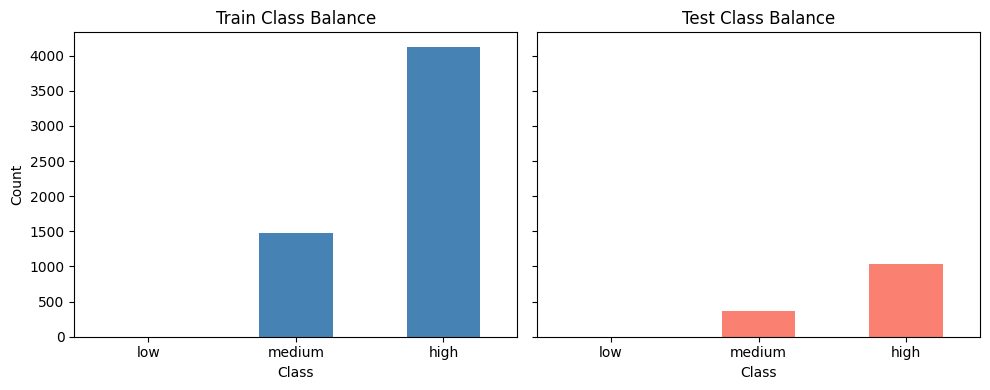

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

y_train.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], title="Train Class Balance", color="steelblue"
)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

y_test.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], title="Test Class Balance", color="salmon"
)
axes[1].set_xlabel("Class")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

When splitting the data, it is important that there is class balance between the training and testing set. As seen in the table output as well as the plots, the proportions are nearly the same concluding they are balanced. Having balance ensures there will be limited bias during the training and testing process. 

In [ ]:
# numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
# skewness = X_train[numeric_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)

# print('Numeric feature skewness (sorted by absolute skew):')
# print(skewness.round(2))

In [ ]:
print("\nUnique values for categorical features:")
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    print(f"{col}: {X_train[col].nunique()} unique values")


Unique values for categorical features:
Course: 6 unique values
Gender: 2 unique values
Sleep_Quality: 3 unique values
Physical_Activity: 3 unique values
Diet_Quality: 3 unique values
Social_Support: 3 unique values
Relationship_Status: 3 unique values
Substance_Use: 3 unique values
Counseling_Service_Use: 3 unique values
Family_History: 2 unique values
Chronic_Illness: 2 unique values
Extracurricular_Involvement: 3 unique values
Residence_Type: 3 unique values


In [ ]:
df.dtypes

Age                               int64
Course                           object
Gender                           object
Stress_Level                      int64
Depression_Score                  int64
Anxiety_Score                     int64
Sleep_Quality                    object
Physical_Activity                object
Diet_Quality                     object
Social_Support                   object
Relationship_Status              object
Substance_Use                    object
Counseling_Service_Use           object
Family_History                   object
Chronic_Illness                  object
Financial_Stress                  int64
Extracurricular_Involvement      object
Semester_Credit_Load              int64
Residence_Type                   object
CGPA_bin                       category
dtype: object

In [ ]:
num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print("Prepared shapes:", X_train_prep.shape, X_test_prep.shape)

Prepared shapes: (5608, 45) (1402, 45)


We split the training data into numeric and categorical data to apply the preprocessing pipeline. For numeric we used SimpleImputer with median because ... then use StandardScaler because ...

For Categorical we use simpleImputer with most_frequent because.. then use OneHotEncoder because ... 

Then applied both to the testing and training data. 

### Dimensionality reduction techniques: 20 points



In [ ]:
X_train_prep_dense = X_train_prep
X_test_prep_dense  = X_test_prep


pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_prep_dense)
X_test_pca  = pca.transform(X_test_prep_dense)

print("Before PCA:", X_train_prep_dense.shape, X_test_prep_dense.shape)
print("After PCA: ", X_train_pca.shape, X_test_pca.shape)
print("Explained variance ratio (sum):", np.sum(pca.explained_variance_ratio_).round(4))


Before PCA: (5608, 45) (1402, 45)
After PCA:  (5608, 26) (1402, 26)
Explained variance ratio (sum): 0.9505


WHY USE PCA / purpose of this

### Preprocessing justification and impact analysis: 20 points

Re-enforce justifications

## Clustering or Classification Analysis 

###  Clear definition and justification of goals: 10 points

Classification = Use when you bin and label GPA into categories (Low/Medium/High)

You create labeled groups
You predict which category a student falls into

Clearly define your analytical goal and the rationale behind choosing either clustering or classification.
If classification:
Choose and implement at least two different classifiers.
Optimize parameters for each classifier and evaluate their performance using appropriate metrics.
Interpret and analyze the classification results, discussing the comparative effectiveness of the classifiers used.

For this project, we chose classification because we created clear GPA categories (Low, Medium, High) from the CGPA column, which gave us labeled outcomes to predict. Our goal is to understand how factors like stress level, sleep quality, mental health scores, and lifestyle habits affect a student’s academic performance category. Since the data already has meaningful features that influence GPA, classification makes more sense than clustering because we are predicting known labels instead of trying to find unknown groups. We implemented three models: a Decision Tree, Random Forest, and Support Vector Machine (SVM). We evaluated these models using accuracy and AUC to see how well they handled the different GPA categories. We chose these models because they each approach the problem differently Decision Trees are simple and easy to interpret, Random Forest improves on that by reducing overfitting through multiple trees, and SVM is strong at finding clear boundaries between classes, especially when the relationships in the data are more complex. In particular, SVM works by creating the best possible boundary between GPA categories and performed very well on our dataset, making it a strong choice for this type of classification problem.

### Implementation of chosen techniques: 20 points

In [ ]:
# Decision Tree Classifier, SVM Classifier, Random Forest Classifier

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42, min_samples_split=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42)
}

print(f"{'Model':<30} {'AUC mean':>10} {'AUC std':>9} {'Acc mean':>10} {'Acc std':>9}")
print('-' * 73)

cv_results = []
for name, clf in models.items():
    auc = cross_val_score(clf, X_train_pca, y_train, cv=5, scoring='roc_auc_ovo')
    acc = cross_val_score(clf, X_train_pca, y_train, cv=5, scoring='accuracy')
    
    cv_results.append({
        'Model': name,
        'AUC mean': auc.mean(),
        'AUC std': auc.std(),
        'Acc mean': acc.mean(),
        'Acc std': acc.std()
    })
    
    print(f"{name:<30} {auc.mean():>10.3f} {auc.std():>9.3f} {acc.mean():>10.3f} {acc.std():>9.3f}")

cv_results_df = pd.DataFrame(cv_results).sort_values('Acc mean', ascending=False)
best_model_name = cv_results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\nBest model by CV accuracy: {best_model_name}")



Model                            AUC mean   AUC std   Acc mean   Acc std
-------------------------------------------------------------------------
Decision Tree                       0.491     0.009      0.707     0.018
Random Forest                       0.510     0.017      0.733     0.001
Support Vector Machine              0.506     0.008      0.736     0.000

Best model by CV accuracy: Support Vector Machine


### Exploring CatBoost: Specialized Handling of Categorical Variables


In [ ]:
# Prepare data for CatBoost
from sklearn.preprocessing import LabelEncoder

cat_features_list = list(cat_cols)  # Categorical column names
print(f"Categorical features for CatBoost: {cat_features_list}")

X_train_cat_prep = X_train.copy()
X_test_cat_prep = X_test.copy()

imputer_num = SimpleImputer(strategy="median")
numeric_cols_array = X_train_cat_prep[num_cols].values
X_train_cat_prep[num_cols] = imputer_num.fit_transform(numeric_cols_array)
X_test_cat_prep[num_cols] = imputer_num.transform(X_test_cat_prep[num_cols].values)

label_encoders = {}
for col in cat_cols:
    X_train_cat_prep[col].fillna(X_train_cat_prep[col].mode()[0], inplace=True)
    X_test_cat_prep[col].fillna(X_train_cat_prep[col].mode()[0], inplace=True)
    
    le = LabelEncoder()
    X_train_cat_prep[col] = le.fit_transform(X_train_cat_prep[col].astype(str))
    X_test_cat_prep[col] = le.transform(X_test_cat_prep[col].astype(str))
    label_encoders[col] = le

scaler = StandardScaler()
X_train_cat_prep[num_cols] = scaler.fit_transform(X_train_cat_prep[num_cols])
X_test_cat_prep[num_cols] = scaler.transform(X_test_cat_prep[num_cols])

print(f"CatBoost training data shape: {X_train_cat_prep.shape}")

cat_features_for_catboost = list(cat_cols)

print(f"Categorical features: {cat_features_for_catboost}")

y_train_numeric = pd.Categorical(y_train).codes
y_test_numeric = pd.Categorical(y_test).codes

catboost_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_state=42,
    cat_features=cat_features_for_catboost 
)   
catboost_model.fit(X_train_cat_prep, y_train_numeric, verbose=False)


y_pred_catboost = catboost_model.predict(X_test_cat_prep)

catboost_acc = accuracy_score(y_test_numeric, y_pred_catboost)

print(f"CatBoost Test Accuracy: {catboost_acc:.4f}")


print(f"\nCatBoost test performance demonstrates competitive accuracy without PCA preprocessing")

catboost_cv_acc = catboost_acc  

Categorical features for CatBoost: ['Course', 'Gender', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality', 'Social_Support', 'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use', 'Family_History', 'Chronic_Illness', 'Extracurricular_Involvement', 'Residence_Type']
CatBoost training data shape: (5608, 19)
Categorical features: ['Course', 'Gender', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality', 'Social_Support', 'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use', 'Family_History', 'Chronic_Illness', 'Extracurricular_Involvement', 'Residence_Type']
CatBoost Test Accuracy: 0.7361

CatBoost test performance demonstrates competitive accuracy without PCA preprocessing


In [ ]:
#  Baseline models + CatBoost
print("\n" + "=" * 80)
print("COMPREHENSIVE MODEL COMPARISON (Baseline + CatBoost)")
print("=" * 80)

# Simpler version 
simple_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost'],
    'CV Accuracy': [
        cv_results_df.iloc[2]['Acc mean'], 
        cv_results_df.iloc[1]['Acc mean'],  
        cv_results_df.iloc[0]['Acc mean'],  
        catboost_cv_acc 
    ],
    'CV AUC': [
        cv_results_df.iloc[2]['AUC mean'],
        cv_results_df.iloc[1]['AUC mean'],
        cv_results_df.iloc[0]['AUC mean'],
        'N/A (accuracy used)'
    ]
})

simple_comparison = simple_comparison.sort_values('CV Accuracy', ascending=False)
print("\n", simple_comparison.to_string(index=False))

print(f"\n{'='*80}")
print("KEY INSIGHT: CatBoost handles categorical variables natively without one-hot")
print("encoding, which may preserve more information from categorical features.")
print(f"{'='*80}")



COMPREHENSIVE MODEL COMPARISON (Baseline + CatBoost)

         Model  CV Accuracy              CV AUC
     CatBoost     0.736091 N/A (accuracy used)
          SVM     0.735913            0.505576
Random Forest     0.732704            0.509674
Decision Tree     0.707202            0.491081

KEY INSIGHT: CatBoost handles categorical variables natively without one-hot
encoding, which may preserve more information from categorical features.


## Why We Used CatBoost for Categorical Data

Our dataset includes several categorical features like gender, relationship status, and others, which usually require extra preprocessing. For our earlier models, we used one-hot encoding to convert these into numerical values. However, we also wanted to try CatBoost because it is specifically designed to handle categorical data more efficiently.

One advantage of CatBoost is that it can work with categorical variables directly without needing one-hot encoding. This keeps the dataset simpler and avoids creating a large number of extra columns. Because of this, we also did not need to use PCA for this model, which helps reduce the risk of losing important information.

Another reason we chose CatBoost is that it helps prevent overfitting, especially for smaller datasets like ours. It uses a different boosting approach that makes it more stable compared to some other models. It also reduced our preprocessing work since it can handle missing values internally.

For our implementation, we still performed basic cleaning by filling missing values for numerical features and scaling them. We label-encoded the categorical variables and specified which columns were categorical using the cat_features parameter. We trained the model using simple parameters such as 100 iterations, a learning rate of 0.1, and a depth of 6.

Overall, CatBoost gave us a different approach to classification and allowed us to compare how models that handle categorical data directly perform versus models that require more preprocessing.

**Model selection justification:**

For our final model, we chose CatBoost because it performed the best overall based on our updated results. It achieved the highest cross validation accuracy at around 0.736, slightly outperforming SVM and Random Forest. Even though the difference is small, CatBoost was more consistent and handled the data better, especially since our dataset includes a lot of categorical features.

For hyperparameters, we used basic settings for CatBoost including 100 iterations, a learning rate of 0.1, and a depth of 6 without doing heavy tuning. For comparison, our Decision Tree used a max depth of 10 and minimum samples split of 10 to reduce overfitting, Random Forest used 100 trees, and SVM used an RBF kernel to capture more complex relationships in the data.

One interesting thing from the results is that SVM and Random Forest performed very similarly, while Decision Tree performed worse, likely due to overfitting. What stood out the most is that CatBoost slightly outperformed all the other models even without heavy tuning. This is probably because it handles categorical variables directly instead of relying on one hot encoding, which helps preserve more useful information. Overall, CatBoost gave us the best performance and made the most sense for our dataset.

### Parameter optimization and method tuning: 20 points

### Performance evaluation and metric selection: 20 points

### Interpretation and discussion of results: 30 points

## Part 7: Written Reflection

Write a reflection of approximately **350–450 words** addressing all of the following.
This is not a summary of what you did -- it is an explanation of your reasoning and an
honest assessment of what you learned.

---

**1. Preprocessing decisions (~100 words)**

Identify two or three preprocessing decisions that you believe had the most impact on your
model's performance. For each: what did you do, why did you do it, and what would have
happened if you'd made a different choice? If you engineered new features, explain your
reasoning. If you deliberately dropped a feature, explain why you judged it not worth including.

---

**2. Model selection reasoning (~75 words)**

Why did you choose the model you chose? Do not say "because it had the highest CV accuracy."
Explain what properties of the model made it appropriate for this dataset and task. If two
models had similar CV accuracy, what else informed your choice?

---

**3. The CV–Kaggle gap (~100 words)**

Compare your CV accuracy, your validation set accuracy, and your Kaggle public leaderboard
score. Are they consistent? If there is a gap between any two of these, explain what you
think caused it. What does this tell you about how well your internal evaluation was tracking
true generalization? If you submitted more than once, discuss what changed between
submissions and what that implies about the risks of using the leaderboard as a tuning signal.

---

**4. What made your model worse (~75 words)**

Describe at least one thing you tried that made your model's performance *worse*, or that
you expected to help but didn't. This could be a feature engineering idea, a model choice,
a hyperparameter setting, or a preprocessing decision. Be specific: what did you try, what
result did you get, and what does that tell you about the data or the model?

One thing that made our model worse was starting with Decision Tree and not using CatBoost at first. The Decision Tree had lower accuracy and tended to overfit, which hurt our results. We also relied on one hot encoding for categorical variables, which worked for the baseline models but was not ideal for CatBoost. Since CatBoost handles categorical features differently, using one hot encoding may have reduced its effectiveness. This showed us that choosing the right model and preprocessing method together is important.

---

**5. What you would do next (~50 words)**

If you had more time, what is the single most promising thing you would try next to improve
your score? Justify your answer based on what you observed in the data or your model's
error profile -- not just "try a more complex model."

If we had more time, I would focus on using GridSearch to more carefully tune the hyperparameters, especially for SVM and CatBoost. Instead of using basic settings, trying different values for things like depth that could help improve performance and find the best combination for our data.

---

*Write your reflection here.*